# Variant Attribution


**Issues**: 
- `hap_matrix` rows should ideally include all haplotypes, not just unique ones. This makes it easier to match up rows to sample IDs with `np.repeat(ds.samples, 2)`.
- When we want to create `hap_matrix` for an entire gene, we want to take the min/max coordinates of all the regions that correspond to that gene and create a new matrix without redundant variant cols. I suppose this could be done by create new GVL datasets with gene-wise start/end coordinates. But if there's a way to this with our existing site-centered GVL datasets that would be nice.
- Currently, if I pass multiple regions to `get_hap_matrix` is grows the matrix along the haplotype dimension (rows). We want it to only grow via the WT variant dimension (cols).
- We'd like to include identifiers for each WT variant (col). e.g. *HGVS:g.5000A>G* or *HGVS:g.77_80del*


---
## 🧬 Definition of Splicing Regions

This table defines and names key genomic regions around splice sites, used for splicing-aware variant annotation and model interpretation.

These regions are defined relative to exon-intron boundaries on the **positive strand (+)**.  
For exons on the **negative strand (-)**, the ranges must be **mirrored** accordingly:

- **Upstream becomes downstream**
- **Start and end positions are interpreted in a strand-aware manner**

| Region Type  | Range (relative to exon-intron boundary on + strand) | Length (bp) | Notes                                      | Short Name    |
|-----------------------------------------------|------------------------------------------------------|-------------|-----------------------------------------------------------|---------------|
| **Canonical 5′ss**                            | `[+1, +2]` (intronic)                                | 2 bp        | Core GT splice site                                       | `5ss_can`     |
| **5′ss intronic proximal**                    | `[+3, +6]` (intronic)                                | 4 bp        | Extended donor consensus                                  | `5ss_iprox`   |
| **5′ss exonic proximal**                      | `[-3, 0]` (exonic)                                   | 3 bp        | Extended donor consensus                      | `5ss_eprox`   |
| **Canonical 3′ss**                            | `[-2, -1]` (intronic)                                | 2 bp        | Core AG splice site                                       | `3ss_can`     |
| **3′ss intronic proximal**                    | `[-17, -3]` (intronic)                               | 15 bp       | Polypyrimidine tract and branchpoint proximity            | `3ss_iprox`   |
| **Branchpoint region**                        | `[-40, -18]` (intronic)                              | 23 bp       | Typical location of lariat-forming branchpoint            | `bp_region`   |
| **3′ss exonic proximal**                      | `[0, +3]` (exonic)                                   | 3 bp        | Extended acceptor consensus                   | `3ss_eprox`   |
| **Exon body excluding 5′ss/3′ss proximal**     | Exon excluding `[-3, +3]` at both ends               | Varies      | Coding region with reduced direct splice regulatory input | `exon_core`   |
---


## 🔖 Notes:

- Ranges are given in **relative coordinates** and must be computed with respect to strand.
- In genomic coordinate systems:
  - For `+` strand exons: ranges apply as shown.
  - For `−` strand exons: ranges must be flipped accordingly, and applied to exon **start** instead of **end** (and vice versa).
- All short names are designed to be used in:
  - BED files (`feature` column)
  - Annotation labels

In [1]:
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True
import pandas as pd
import polars as pl
import numpy as np
import glob 
from tqdm import tqdm 
import seaborn as sns
import matplotlib.pyplot as plt
import pooch

import src.utils as utils
import src.vep_analysis as va
import src.clinvar as cv
import src.onekg as og
import src.benchmark.clinvar as bcv
import src.GVL as GVL
import src.analysis.attribution as ab
import src.analysis.matrices as mc


pd.set_option('display.max_columns', None)
plt.rcParams['font.family'] =  'Nimbus Sans'

import genvarloader as gvl
import awkward as ak

/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/sorted_nearest/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Sync data from OneDrive to local.

In [2]:
# %%bash

# rclone sync onedrive:VEP_DNA/1000_Genomes_on_GRCh38/SpliceAI/data/ $HOME/projects/data/1000_Genomes_on_GRCh38/SpliceAI/data

## Determine genes of interest

Grab the region that corresponds to the one centered on each clinical variant.

Sort genes based on how many pathogenic variants that have, as these are less common in ClinvVar than benign variants (at least in UTRs).

In [2]:
## Select chrom of interest
chrom="chr17"

bed = pd.read_csv("data/splicing/splicevardb_x_clinvar_variants.csv.gz")

bed = utils.add_variant_name(bed, chrom_col="chr", start_col="pos", end_col=None, ref_col="ref", alt_col="alt", alias="site")
bed.rename(columns={"chr":"chrom","gene":"GENE","CLNSIG_simplified":"CLNSIG_simple"}, inplace=True)
site_counts = bed.groupby(["chrom","GENE","CLNSIG_simple"])["site"].nunique().sort_values(ascending=False).rename("n_sites").reset_index()
# # For each GENE, count the ratio of pathogenic to benign n_sites

# # First, filter for pathogenic and benign rows
path_mask = site_counts["CLNSIG_simple"].str.lower().str.contains("path")
benign_mask = site_counts["CLNSIG_simple"].str.lower().str.contains("benign")

# # Aggregate n_sites for each gene and class
gene_path = site_counts[path_mask].groupby(["chrom","GENE"])["n_sites"].sum().rename("n_path")
gene_benign = site_counts[benign_mask].groupby(["chrom","GENE"])["n_sites"].sum().rename("n_benign")

# Combine into a single DataFrame
gene_counts = pd.concat([gene_path, gene_benign], axis=1).fillna(0)

# Compute the ratio
gene_counts["path_to_benign_ratio"] = gene_counts["n_path"] / gene_counts["n_benign"].replace(0, np.nan)

# Optionally, sort by ratio descending
gene_counts = gene_counts.sort_values("n_path", ascending=False).reset_index()

print(gene_counts)  


## Get the top gene on the chromosome of interest
gene = gene_counts.loc[gene_counts["chrom"].str.replace("chr", "") == chrom.replace("chr", "")]['GENE'].values[0]
print("GENE:", gene)

      chrom    GENE  n_path  n_benign  path_to_benign_ratio
0     chr17   BRCA1   148.0     138.0              1.072464
1     chr17     NF1   124.0       4.0             31.000000
2     chr13   BRCA2   113.0      84.0              1.345238
3      chr3  COL7A1    91.0       5.0             18.200000
4      chr3    MLH1    69.0      25.0              2.760000
...     ...     ...     ...       ...                   ...
1304   chr9   PMPCA     0.0       2.0              0.000000
1305   chr9    NEK6     0.0       1.0              0.000000
1306   chr9  LRSAM1     0.0       7.0              0.000000
1307   chr9   FOCAD     0.0       3.0              0.000000
1308   chr9    ELP1     0.0       2.0              0.000000

[1309 rows x 5 columns]
GENE: BRCA1


In [3]:
bed.groupby(["MC","CLNSIG_simple"])["site"].nunique()

MC                                                                                                       CLNSIG_simple
SO:0001574|splice_acceptor_variant                                                                       pathogenic       179
                                                                                                         vus               12
SO:0001574|splice_acceptor_variant,SO:0001583|missense_variant                                           vus                1
SO:0001574|splice_acceptor_variant,SO:0001583|missense_variant,SO:0001619|non-coding_transcript_variant  pathogenic         1
SO:0001574|splice_acceptor_variant,SO:0001623|5_prime_UTR_variant                                        pathogenic         2
                                                                                                                         ... 
SO:0001819|synonymous_variant                                                                            benign           757

In [5]:
window_size = 10000

# #### Take the union of all windows
gene_min_pos = bed.loc[bed["GENE"]==gene]["pos"].min() - (window_size//2)
gene_max_pos = bed.loc[bed["GENE"]==gene]["pos"].max() + (window_size//2)

#### Take the intersection of all windows
# gene_min_pos = bed.loc[bed["GENE"]==gene]["pos"].max() - (window_size//2)
# gene_max_pos = bed.loc[bed["GENE"]==gene]["pos"].min() + (window_size//2)

# cohort = "1000_Genomes_on_GRCh38"
# gene_coords = pd.read_csv(os.path.expanduser(f"~/projects/data/{cohort}/SpliceAI/data/annotation/hg38_genes_and_exons.txt"),sep="\t")
# gene_coords["length"] = abs(gene_coords["TX_END"] - gene_coords["TX_START"])
# gene_min_pos = gene_coords.loc[gene_coords["#NAME"]==gene]["TX_START"].values[0] - (window_size//2)
# gene_max_pos = gene_coords.loc[gene_coords["#NAME"]==gene]["TX_END"].values[0]  + (window_size//2)


print(gene_min_pos, gene_max_pos, abs(gene_min_pos-gene_max_pos))

43040802 43129125 88323


## Create haplotype x WT variant matrix: `scikit-allel`

HINT: Install tabix via `htslib` to massively speed up queries:

`conda install bioconda::htslib`

See here for more info on working with `scikit-allel` data structures:  
https://alimanfoo.github.io/2017/06/14/read-vcf.html

NOTES: 
- `scikit-allel` has technically been deprecated, and succeeded by [`sgkit`](https://sgkit-dev.github.io/sgkit/latest/), though it still works surprisingly well.
- WARNING: Be careful installing `scikit-allel` in the same environment as GVL or Flashzoi as its dependency (`scipy`) maty cause version conflicts.

In [6]:
import allel
import sys 

vcf_paths = {
    # os.path.expanduser(f"~/projects/data/1000_Genomes_on_GRCh38/SpliceAI/data/splicevardb_x_clinvar/splicevardb_x_clinvar_snv_{chrom}.atomized.vcf.gz")
    "1KGP": os.path.expanduser(f"~/projects/data/1000_Genomes_on_GRCh38/vcf/ALL.{chrom}.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.vcf.gz"),
    "HGDP": os.path.expanduser(f"~/projects/data/Human_Genome_Diversity_Project/vcf/hgdp_wgs.20190516.statphase.autosomes.vcf.gz"),
} 

Xwt = pd.DataFrame()
for cohort, vcf_path in vcf_paths.items():
    print(f"Processing {cohort}...")

    if cohort == "1KGP":
        chrom_str = chrom.replace('chr', '')
    else:
        chrom_str = chrom
    # Load the VCF data for the specified region 
    callset = allel.read_vcf(
        vcf_path,
        region=f"{chrom_str}:{gene_min_pos}-{gene_max_pos}", 
        log=sys.stdout
    ) 

    # Create unique IDs for each WT variant
    vcf_df = allel.vcf_to_dataframe(vcf_path,  
                                    region=f"{chrom_str}:{gene_min_pos}-{gene_max_pos}")
    vcf_df = utils.add_variant_name(vcf_df, 
                                    chrom_col="CHROM",
                                    start_col="POS",
                                    end_col=None,
                                    ref_col="REF",
                                    alt_col="ALT_1",
                                    alias="site") 

    # Convert genotypes to matrix format and create a DataFrame
    gt = allel.GenotypeArray(callset['calldata/GT'])
    Xwt_tmp = pd.DataFrame(
        gt.to_sparse().T.toarray(),
        columns=vcf_df['site'].values,
        index=np.array([f"{sample}_{i}" for sample in callset['samples'] for i in range(2)])
    ) 
    Xwt = pd.concat([Xwt, Xwt_tmp], axis=0) 

Xwt.fillna(0, inplace=True)
# -1 is missing data
Xwt.replace(-1, 0, inplace=True)

print(Xwt.shape)
Xwt.iloc[:10,:10]

Processing 1KGP...
[read_vcf] 2172 rows in 0.64s; chunk in 0.64s (3375 rows/s)
[read_vcf] all done (3372 rows/s)


/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/allel/io/vcf_read.py:1787: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace('', np.nan, inplace=True)


Processing HGDP...
[read_vcf] 1732 rows in 0.21s; chunk in 0.21s (8297 rows/s)
[read_vcf] all done (8279 rows/s)


/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/allel/io/vcf_read.py:1787: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace('', np.nan, inplace=True)


(6954, 3109)


,chr17:43040838-43040839_G_A,chr17:43040839-43040840_G_GTA,chr17:43041060-43041061_T_C,chr17:43041129-43041130_C_G,chr17:43041138-43041139_C_T,chr17:43041144-43041145_A_G,chr17:43041181-43041182_G_A,chr17:43041194-43041195_C_A,chr17:43041273-43041277_TAAC_T,chr17:43041320-43041321_G_A
HG00096_0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
HG00096_1,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
HG00097_0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
HG00097_1,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
HG00099_0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
HG00099_1,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
HG00100_0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
HG00100_1,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
HG00101_0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
HG00101_1,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## Create haplotype x WT variant matrix: `genvarloader`

In [ ]:
from src.SpliceAI.src.dataset import SpliceHapDataset
from pathlib import Path


chrom = bed.loc[bed["GENE"]==gene].chrom.iloc[0]

root_dir = Path(os.path.expanduser("~/projects/data/1000_Genomes_on_GRCh38/SpliceAI"))

data_dir = root_dir / "data/gvl_1kgp/1kgp_gvl/"
zip_path = Path(str(data_dir) + ".zip")
out_dir = root_dir / Path("out")

# Unzip the data if it's not already unzipped
if not data_dir.exists() or not any(data_dir.iterdir()):
    import zipfile
    print(f"Unzipping {zip_path} to {data_dir} ...")
    with zipfile.ZipFile(str(zip_path), 'r') as zip_ref:
        zip_ref.extractall(str(data_dir))


# 1. Get the path for 1KGP reference genome   
cohort = "1000_Genomes_on_GRCh38"
reference_path = pooch.retrieve(
        url=og.get_ftp_dict()[cohort]['ref'],
        known_hash=None,
        progressbar=True
    )
reference_bgz = Path(f"{reference_path}.bgz")
# Loop through each chromosome 
print(f"\n🔄 Processing {chrom}...")

variant_path = root_dir / Path(f"./data/splicevardb_x_clinvar/splicevardb_x_clinvar_snv_{chrom}.atomized.vcf.gz")
hap_pgen_path = root_dir / Path(f"./data/1000_Genomes_on_GRCh38/vcf/ALL.{chrom}.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.vcf.atomized.vcf.gz")
region_bed_path = root_dir / Path(f"./data/splicevardb_x_clinvar/splicevardb_x_clinvar_snv_{chrom}_region_bed.bed")
annotation_bed_path = [
    ("3pss", f"{root_dir}/data/annotation/p3_{chrom}_bed.bed"),
    ("5pss", f"{root_dir}/data/annotation/p5_{chrom}_bed.bed")
]

dataset_path = data_dir / f"{chrom}_dataset.gvl"
output_path = out_dir / f"{chrom}_results.parquet"

 # Build the dataset
dataset = SpliceHapDataset.build_from_files_with_matching_sites(
    reference_path=str(reference_path),
    region_bed_path=str(region_bed_path),
    hap_pgen_path=str(hap_pgen_path),
    variant_path=str(variant_path),
    window_size=50,
    context_size=5000,
    bed_paths=annotation_bed_path,
    dataset_path=str(dataset_path),
    ploidy=2,
    deduplicate=False,
    remake_dataset=False,  # Set False in future to avoid rebuilding
    num_workers=0,
    enable_profiling=False,
    enable_cache=True
)

site_ds = dataset.gvl

Unzipping /home/schilder/projects/data/1000_Genomes_on_GRCh38/SpliceAI/data/gvl_1kgp/1kgp_gvl.zip to /home/schilder/projects/data/1000_Genomes_on_GRCh38/SpliceAI/data/gvl_1kgp/1kgp_gvl ...


2025-09-26 12:30:39.665 | INFO     | genvarloader._dataset._reconstruct:from_path:215 - Loading variant data.
2025-09-26 12:30:39.732 | INFO     | genvarloader._dataset._impl:open:252 - Opened dataset:
GVL store at /home/schilder/projects/data/1000_Genomes_on_GRCh38/SpliceAI/data/gvl_1kgp/1kgp_gvl/chr17_dataset.gvl
Is subset: False
# of regions: 897
# of samples: 2548
Output length: ragged
Jitter: 0 (max: 0)
Deterministic: True
Sequence type: reference haplotypes annotated [variants]
Active tracks: 3pss_neg, 3pss_pos, 5pss_neg, 5pss_pos
Tracks available: 3pss_neg, 3pss_pos, 5pss_neg, 5pss_pos




🔄 Processing chr17...


Reading records:   0%|          | 0/897 [00:00<?, ? record/s]

In [15]:
# Subset the GVL dataset to a regions of interest for a specific gene and compute the binarized haplotype x WT variant matrix.
region_to_site = GVL.filter_region_to_site(site_ds.rows) 
roi = region_to_site.filter(pl.col("chromStart") >= gene_min_pos,
                            pl.col("chromEnd") <= gene_max_pos
     )
print(roi.shape)
roi

Sites before filter_region_to_site:  (49585, 8)
Sites after site_filters:  (897, 9)
Sites after region_idx==site_idx filter:  (897, 9)
(227, 9)


index,region_idx,chrom,chromStart,chromEnd,site_idx,REF,ALT,POS0
u32,u32,cat,i64,i64,u32,str,str,i64
11620,408,"""chr17""",43042035,43072036,408,"""G""","""C""",43057034
11757,409,"""chr17""",43042037,43072038,409,"""G""","""A""",43057036
11894,410,"""chr17""",43042046,43072047,410,"""C""","""G""",43057045
12031,411,"""chr17""",43042051,43072052,411,"""C""","""T""",43057050
12168,412,"""chr17""",43042052,43072053,412,"""C""","""A""",43057051
…,…,…,…,…,…,…,…,…
39053,630,"""chr17""",43091529,43121530,630,"""A""","""C""",43106528
39187,631,"""chr17""",43091533,43121534,631,"""T""","""A""",43106532
39321,632,"""chr17""",43091534,43121535,632,"""C""","""G""",43106533


In [ ]:
from genoray import VCF

vcf_path = os.path.expanduser(f"~/projects/data/1000_Genomes_on_GRCh38/vcf/ALL.{chrom}.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.vcf.gz")
vcf = VCF(vcf_path)

hap_ids, hap_membership, hap_matrix, col_v_idxs = GVL.get_merged_hap_xr(
    vcf = vcf, 
    ds = site_ds.dataset, 
    regions = roi["region_idx"].to_list(), 
    samples = slice(None),
    verbose = True
)

2025-09-26 12:33:08.058 | INFO     | genoray._vcf:_load_index:1076 - Loading genoray index.


[get_merged_hap_xr] VCF index loaded and validated.
[get_merged_hap_xr] Parsing index for regions and samples.
[get_merged_hap_xr] Calculating intersection of genotypes.


ValueError: cannot broadcast nested list (in compiled code: https://github.com/scikit-hep/awkward/blob/awkward-cpp-46/awkward-cpp/src/cpu-kernels/awkward_ListArray_broadcast_tooffsets.cpp#L27)

Create named df from hap_matrix.

In [10]:
Xwt = GVL.hap_xr_to_df(hap_matrix)
print(Xwt.shape)
Xwt.iloc[:10, :10]

(5096, 14670)


,chr17:7414521-7414522_C_T,chr17:7414534-7414535_G_A,chr17:7414555-7414556_G_T,chr17:7414612-7414613_G_A,chr17:7414619-7414620_C_T,chr17:7414639-7414640_G_A,chr17:7414675-7414676_C_T,chr17:7414741-7414742_T_C,chr17:7414771-7414772_C_T,chr17:7414772-7414773_G_A
HG00096_0,False,False,False,True,False,False,False,False,False,False
HG00096_1,False,False,False,False,False,False,False,False,False,False
HG00097_0,False,False,False,False,False,False,False,True,False,False
HG00097_1,False,False,False,False,False,False,False,False,False,False
HG00099_0,False,False,False,False,False,False,False,False,False,False
HG00099_1,False,False,False,False,False,False,False,False,False,False
HG00100_0,False,False,False,False,False,False,False,False,False,False
HG00100_1,False,False,False,False,False,False,False,False,False,False
HG00101_0,False,False,False,False,False,False,False,False,False,False
HG00101_1,False,False,False,False,False,False,False,False,False,False


In [11]:
Xwt.sum(axis=0).describe()

count    14670.000000
mean       186.772256
std        701.646584
min          1.000000
25%          1.000000
50%          2.000000
75%         11.000000
max       5096.000000
dtype: float64

Count the number of variants in which there is no variation.

These are probably cases where almost everyone has the non-REF allele (i.e. the REF is not representative of population-derived data).

In [12]:
n_invariant_variants = (Xwt.nunique(axis=0) == 1).sum()
print(f"Number of variants with no variation (invariant columns): {n_invariant_variants}")


Number of variants with no variation (invariant columns): 2


## Read in VEP data

In [7]:
spliceai_df_path = "../data/1000_Genomes_on_GRCh38/SpliceAI/spliceai_clinvar_merged.parquet"
spliceai_df = pd.read_parquet(spliceai_df_path)

# Standardise clinical significance labels
spliceai_df["clinsig"] = spliceai_df["CLNSIG_simplified"].astype(str)
likely_mask = spliceai_df["CLNSIG"].str.lower().str.contains("likely").fillna(False)
spliceai_df.loc[likely_mask, "clinsig"] = "likely_"+spliceai_df.loc[likely_mask, "clinsig"]
spliceai_df.replace({"clinsig": {"vus": "VUS"}}, inplace=True)
spliceai_df = spliceai_df[~spliceai_df["clinsig"].isin([np.str_('nan'), 'nan'])]
spliceai_df["clinsig_simple"] = spliceai_df["clinsig"].str.replace("likely_", "")
spliceai_df.rename(columns={"hap_id": "ploid"}, inplace=True) 

vep_df = spliceai_df


/tmp/ipykernel_1052889/2158785671.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  likely_mask = spliceai_df["CLNSIG"].str.lower().str.contains("likely").fillna(False)


In [8]:
y_vep = vep_df.loc[vep_df["site"].isin(bed.loc[bed["GENE"] == gene]["site"])].pivot_table(
    index=["sample", "ploid"], 
    columns="site", 
    values="VEP"
)
# Flatten the MultiIndex for the rows
y_vep.index = [f"{s}_{p}" for s, p in y_vep.index]
print(y_vep.shape)
y_vep.head()

/tmp/ipykernel_1052889/696032773.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  y_vep = vep_df.loc[vep_df["site"].isin(bed.loc[bed["GENE"] == gene]["site"])].pivot_table(


(6941, 302)


site,chr17:43045803-43045804_C_T,chr17:43045804-43045805_T_C,chr17:43045810-43045811_C_T,chr17:43045812-43045813_G_T,chr17:43047634-43047635_G_T,chr17:43047638-43047639_C_G,chr17:43047641-43047642_A_G,chr17:43047642-43047643_C_T,chr17:43047643-43047644_C_T,chr17:43047657-43047658_T_C,chr17:43047661-43047662_C_A,chr17:43047665-43047666_C_T,chr17:43047676-43047677_G_C,chr17:43047678-43047679_T_C,chr17:43047679-43047680_G_A,chr17:43047681-43047682_A_C,chr17:43047698-43047699_G_A,chr17:43047699-43047700_A_T,chr17:43047702-43047703_C_G,chr17:43047705-43047706_T_C,chr17:43049113-43049114_A_G,chr17:43049116-43049117_C_G,chr17:43049117-43049118_T_C,chr17:43049118-43049119_T_A,chr17:43049119-43049120_A_C,chr17:43049120-43049121_C_T,chr17:43049150-43049151_T_A,chr17:43049164-43049165_C_A,chr17:43049174-43049175_G_A,chr17:43049181-43049182_C_T,chr17:43049182-43049183_C_T,chr17:43049188-43049189_A_G,chr17:43049193-43049194_A_G,chr17:43049195-43049196_C_A,chr17:43049196-43049197_T_C,chr17:43049197-43049198_A_C,chr17:43051048-43051049_C_G,chr17:43051050-43051051_C_A,chr17:43051061-43051062_A_T,chr17:43051062-43051063_C_T,chr17:43051063-43051064_C_G,chr17:43051063-43051064_C_T,chr17:43051071-43051072_A_C,chr17:43051071-43051072_A_T,chr17:43051088-43051089_A_T,chr17:43051098-43051099_A_C,chr17:43051102-43051103_C_A,chr17:43051104-43051105_A_G,chr17:43051118-43051119_C_A,chr17:43051131-43051132_G_C,chr17:43057035-43057036_G_C,chr17:43057037-43057038_G_A,chr17:43057046-43057047_C_G,chr17:43057051-43057052_C_T,chr17:43057052-43057053_C_A,chr17:43057055-43057056_T_C,chr17:43057063-43057064_G_A,chr17:43057069-43057070_C_A,chr17:43057070-43057071_T_C,chr17:43057075-43057076_C_G,chr17:43057077-43057078_C_T,chr17:43057078-43057079_G_A,chr17:43057083-43057084_G_C,chr17:43057086-43057087_C_T,chr17:43057093-43057094_G_T,chr17:43057107-43057108_A_C,chr17:43057112-43057113_A_C,chr17:43057113-43057114_T_C,chr17:43057114-43057115_C_A,chr17:43057116-43057117_C_T,chr17:43057117-43057118_C_T,chr17:43057122-43057123_A_C,chr17:43057122-43057123_A_G,chr17:43057131-43057132_T_C,chr17:43057136-43057137_C_A,chr17:43057147-43057148_C_T,chr17:43057153-43057154_C_T,chr17:43057169-43057170_G_A,chr17:43063331-43063332_A_C,chr17:43063347-43063348_T_A,chr17:43063368-43063369_T_C,chr17:43063369-43063370_C_A,chr17:43063372-43063373_C_A,chr17:43063373-43063374_C_A,chr17:43063373-43063374_C_T,chr17:43063374-43063375_C_T,chr17:43063379-43063380_G_T,chr17:43063869-43063870_C_G,chr17:43063873-43063874_C_G,chr17:43063878-43063879_A_C,chr17:43063883-43063884_T_G,chr17:43063890-43063891_C_T,chr17:43063898-43063899_C_A,chr17:43063902-43063903_C_T,chr17:43063903-43063904_G_T,chr17:43063909-43063910_C_G,chr17:43063917-43063918_A_C,chr17:43063929-43063930_C_T,chr17:43063931-43063932_G_A,chr17:43063937-43063938_A_G,chr17:43063946-43063947_C_A,chr17:43063953-43063954_T_C,chr17:43063959-43063960_A_C,chr17:43063960-43063961_T_A,chr17:43064058-43064059_T_C,chr17:43067551-43067552_G_A,chr17:43067602-43067603_G_C,chr17:43067603-43067604_T_A,chr17:43067605-43067606_T_C,chr17:43067607-43067608_C_A,chr17:43067608-43067609_C_A,chr17:43067610-43067611_G_A,chr17:43067616-43067617_A_C,chr17:43067624-43067625_A_T,chr17:43067628-43067629_G_A,chr17:43067629-43067630_T_C,chr17:43067635-43067636_C_A,chr17:43067658-43067659_G_A,chr17:43067660-43067661_G_A,chr17:43067683-43067684_T_A,chr17:43067690-43067691_G_A,chr17:43067694-43067695_A_T,chr17:43067695-43067696_T_A,chr17:43067696-43067697_C_T,chr17:43067697-43067698_T_C,chr17:43067698-43067699_G_C,chr17:43067715-43067716_T_C,chr17:43070909-43070910_T_C,chr17:43070922-43070923_A_C,chr17:43070924-43070925_T_C,chr17:43070925-43070926_C_G,chr17:43070927-43070928_C_A,chr17:43070929-43070930_A_G,chr17:43071046-43071047_G_C,chr17:43071148-43071149_C_T,chr17:43071232-43071233_G_A,chr17:43074320-43074321_T_C,chr17:43074324-43074325_A_G,chr17:43074328-43074329_T_A,chr17:43074330-43074331_C_G,chr17:43074331-43074332_C_G,chr17:43074404-43074405_C_T,chr17:43074522-4307

## Train ridge regression model

Separate ridge regression models for each clinical variant.

In [9]:
models = {}
for y in tqdm(y_vep.columns):
    x_pos = Xwt.columns.str.split(":").str[1].str.split("-").str[0].astype(int)
    y_pos = int(y.split(":")[1].split("-")[0]) 
    # only use WT variants that are <5kb away from the clinical variant of interest
    x_mask = (abs(x_pos - y_pos) <= 5000) 
    models[y] = ab.wtvariants_to_vep_linear_model(Xwt.loc[:, x_mask], y_vep[[y]], add_positions=True, verbose=False)
    

  0%|          | 0/302 [00:00<?, ?it/s]

100%|██████████| 302/302 [00:27<00:00, 10.84it/s]


Merge all ridge model results into a single dataframe

In [10]:
ridge_df = pd.concat([x["interaction_df"] for x in models.values()], axis=0).sort_values(by="interaction_strength", ascending=False)
ridge_df = ridge_df.merge(bed, on="site",how="left") 

# Remove rows where the WT and clinical positions are the same
print(ridge_df.shape)
ridge_df = ridge_df.loc[ridge_df["wt_position"] != ridge_df["clinical_position"]]
print(ridge_df.shape)
ridge_df.head()

(104824, 58)
(104769, 58)


,wt_variant,site,interaction_strength,interaction_strength_signed,outlier_type,n_haplotypes,interaction_strength_weighted,clinical_variant,wt_position,clinical_position,position_distance,chrom,pos,clinvar_id,ref,alt,qual,filter,info,3ss_can,3ss_eprox,3ss_iprox,bp_region,5ss_can,5ss_eprox,5ss_iprox,exon_core,svdb_id,GENE,hgvs,method,spliceogenicity,location,doi,CLNHGVS,GENEINFO,AF_EXAC,CLNSIG,CLNDN,CLNDISDB,CLNREVSTAT,CLNSIGCONF,CLNVC,CLNVCSO,MC,ONC,ONCDN,ONCDISDB,ONCREVSTAT,ONCCONF,ORIGIN,SCI,SCIDN,SCIDISDB,SCIREVSTAT,CLNSIG_simple,ONC_simplified,SCI_simplified
0,chr17:43115789-43115790_T_G,chr17:43115788-43115789_G_C,0.650754,-0.650754,more pathogenic,2.0,1.140836,chr17:43115788-43115789_G_C,43115789,43115788,1,chr17,43115788,55719,G,C,.,.,ALLELEID=70386;CLNDISDB=MedGen:C3661900|MONDO:...,0,0,1,0,0,0,0,0,21284,BRCA1,NM_007294.4:c.81-9C>G,RT-PCR,Splice-altering,Intronic,10.1093/nar/gky372,NC_000017.11:g.43115788G>C,BRCA1:672,NaN,Pathogenic,"not_provided|Breast-ovarian_cancer,_familial,_...","MedGen:C3661900|MONDO:MONDO:0011450,MedGen:C26...",3,NaN,single_nucleotide_variant,SO:0001483,SO:0001627|intron_variant,None,None,None,None,NaN,1.0,None,NaN,NaN,None,pathogenic,None,None
3,chr17:43066089-43066090_G_A,chr17:43067551-43067552_G_A,0.248612,-0.248612,more pathogenic,2.0,0.705142,chr17:43067551-43067552_G_A,43066089,43067551,1462,chr17,43067551,2075140,G,A,.,.,"ALLELEID=2134255;CLNDISDB=MONDO:MONDO:0003582,...",0,0,0,0,0,0,0,0,20978,BRCA1,NM_007294.4:c.5074+57C>T,RNA-Seq,Low-frequency,Intronic,10.1101/gr.231951.117,NC_000017.11:g.43067551G>A,BRCA1:672,NaN,Benign,Hereditary_breast_ovarian_cancer_syndrome,"MONDO:MONDO:0003582,MeSH:D061325,MedGen:C06777...",1,NaN,single_nucleotide_variant,SO:0001483,SO:0001627|intron_variant,None,None,None,None,NaN,1.0,None,NaN,NaN,None,benign,None,None
4,chr17:43047712-43047713_C_T,chr17:43047705-43047706_T_C,0.185772,-0.185772,more pathogenic,1.0,0.431013,chr17:43047705-43047706_T_C,43047712,43047705,7,chr17,43047705,55567,T,C,.,.,ALLELEID=70234;CLNDISDB=MedGen:C3661900|MONDO:...,1,0,0,0,0,0,0,0,20850,BRCA1,NM_007294.4:c.5407-2A>G,RT-PCR,Splice-altering,Intronic,10.1093/nar/gky372,NC_000017.11:g.43047705T>C,BRCA1:672,NaN,Pathogenic/Likely_pathogenic,"not_provided|Breast-ovarian_cancer,_familial,_...","MedGen:C3661900|MONDO:MONDO:0011450,MedGen:C26...",2,NaN,single_nucleotide_variant,SO:0001483,SO:0001574|splice_acceptor_variant,None,None,None,None,NaN,1.0,None,NaN,NaN,None,pathogenic,None,None
5,chr17:43124063-43124064_G_A,chr17:43124016-43124017_C_T,0.131335,-0.131335,more pathogenic,1.0,0.362401,chr17:43124016-43124017_C_T,43124063,43124016,47,chr17,43124016,55710,C,T,.,.,"ALLELEID=70377;CLNDISDB=MONDO:MONDO:0011450,Me...",0,0,0,0,1,0,0,0,21293,BRCA1,NM_007294.4:c.80+1G>A,"RNA-Seq,RT-PCR",Splice-altering,Intronic,"10.1093/nar/gky372,10.1101/gr.231951.117",NC_000017.11:g.43124016C>T,BRCA1:672,NaN,Pathogenic/Likely_pathogenic,"Breast-ovarian_cancer,_familial,_susceptibilit...","MONDO:MONDO:0011450,MedGen:C2676676,OMIM:60437...",2,NaN,single_nucleotide_variant,SO:0001483,"SO:0001575|splice_donor_variant,SO:0001627|int...",None,None,None,None,NaN,1.0,None,NaN,NaN,None,pathogenic,None,None
6,chr17:43106492-43106493_G_A,chr17:43106534-43106535_C_G,0.110552,-0.110552,more pathogenic,1.0,0.332493,chr17:43106534-43106535_C_G,43106492,43106534,42,chr17,43106534,54215,C,G,.,.,ALLELEID=68882;CLNDISDB=MedGen:C3661900|MONDO:...,1,0,1,0,0,0,0,0,21259,BRCA1,NM_007294.4:c.135-1G>C,RT-PCR,Splice-altering,Intronic,10.1093/nar/gky372,NC_000017.11:g.43106534C>G,BRCA1:672,NaN,Pathogenic,"not_provided|Breast-ovarian_cancer,_familial,_...","MedGen:C3661900|MONDO:MONDO:0011450,MedGen:C26...",2,NaN,single_nucleotide_variant,SO:0001483,"SO:0001574|splice_acceptor_variant,SO:0001627|...",None,None,None,None,NaN,1.0,None,NaN,NaN,None,pathogenic,None,None


Merge all interaction matrices into a single dataframe.

In [11]:
Xcoef = pd.concat([x["coef_matrix_abs"] for x in models.values()], axis=1)
print(Xcoef.shape)
Xcoef.head() 

(3109, 302)


site,chr17:43045803-43045804_C_T,chr17:43045804-43045805_T_C,chr17:43045810-43045811_C_T,chr17:43045812-43045813_G_T,chr17:43047634-43047635_G_T,chr17:43047638-43047639_C_G,chr17:43047641-43047642_A_G,chr17:43047642-43047643_C_T,chr17:43047643-43047644_C_T,chr17:43047657-43047658_T_C,chr17:43047661-43047662_C_A,chr17:43047665-43047666_C_T,chr17:43047676-43047677_G_C,chr17:43047678-43047679_T_C,chr17:43047679-43047680_G_A,chr17:43047681-43047682_A_C,chr17:43047698-43047699_G_A,chr17:43047699-43047700_A_T,chr17:43047702-43047703_C_G,chr17:43047705-43047706_T_C,chr17:43049113-43049114_A_G,chr17:43049116-43049117_C_G,chr17:43049117-43049118_T_C,chr17:43049118-43049119_T_A,chr17:43049119-43049120_A_C,chr17:43049120-43049121_C_T,chr17:43049150-43049151_T_A,chr17:43049164-43049165_C_A,chr17:43049174-43049175_G_A,chr17:43049181-43049182_C_T,chr17:43049182-43049183_C_T,chr17:43049188-43049189_A_G,chr17:43049193-43049194_A_G,chr17:43049195-43049196_C_A,chr17:43049196-43049197_T_C,chr17:43049197-43049198_A_C,chr17:43051048-43051049_C_G,chr17:43051050-43051051_C_A,chr17:43051061-43051062_A_T,chr17:43051062-43051063_C_T,chr17:43051063-43051064_C_G,chr17:43051063-43051064_C_T,chr17:43051071-43051072_A_C,chr17:43051071-43051072_A_T,chr17:43051088-43051089_A_T,chr17:43051098-43051099_A_C,chr17:43051102-43051103_C_A,chr17:43051104-43051105_A_G,chr17:43051118-43051119_C_A,chr17:43051131-43051132_G_C,chr17:43057035-43057036_G_C,chr17:43057037-43057038_G_A,chr17:43057046-43057047_C_G,chr17:43057051-43057052_C_T,chr17:43057052-43057053_C_A,chr17:43057055-43057056_T_C,chr17:43057063-43057064_G_A,chr17:43057069-43057070_C_A,chr17:43057070-43057071_T_C,chr17:43057075-43057076_C_G,chr17:43057077-43057078_C_T,chr17:43057078-43057079_G_A,chr17:43057083-43057084_G_C,chr17:43057086-43057087_C_T,chr17:43057093-43057094_G_T,chr17:43057107-43057108_A_C,chr17:43057112-43057113_A_C,chr17:43057113-43057114_T_C,chr17:43057114-43057115_C_A,chr17:43057116-43057117_C_T,chr17:43057117-43057118_C_T,chr17:43057122-43057123_A_C,chr17:43057122-43057123_A_G,chr17:43057131-43057132_T_C,chr17:43057136-43057137_C_A,chr17:43057147-43057148_C_T,chr17:43057153-43057154_C_T,chr17:43057169-43057170_G_A,chr17:43063331-43063332_A_C,chr17:43063347-43063348_T_A,chr17:43063368-43063369_T_C,chr17:43063369-43063370_C_A,chr17:43063372-43063373_C_A,chr17:43063373-43063374_C_A,chr17:43063373-43063374_C_T,chr17:43063374-43063375_C_T,chr17:43063379-43063380_G_T,chr17:43063869-43063870_C_G,chr17:43063873-43063874_C_G,chr17:43063878-43063879_A_C,chr17:43063883-43063884_T_G,chr17:43063890-43063891_C_T,chr17:43063898-43063899_C_A,chr17:43063902-43063903_C_T,chr17:43063903-43063904_G_T,chr17:43063909-43063910_C_G,chr17:43063917-43063918_A_C,chr17:43063929-43063930_C_T,chr17:43063931-43063932_G_A,chr17:43063937-43063938_A_G,chr17:43063946-43063947_C_A,chr17:43063953-43063954_T_C,chr17:43063959-43063960_A_C,chr17:43063960-43063961_T_A,chr17:43064058-43064059_T_C,chr17:43067551-43067552_G_A,chr17:43067602-43067603_G_C,chr17:43067603-43067604_T_A,chr17:43067605-43067606_T_C,chr17:43067607-43067608_C_A,chr17:43067608-43067609_C_A,chr17:43067610-43067611_G_A,chr17:43067616-43067617_A_C,chr17:43067624-43067625_A_T,chr17:43067628-43067629_G_A,chr17:43067629-43067630_T_C,chr17:43067635-43067636_C_A,chr17:43067658-43067659_G_A,chr17:43067660-43067661_G_A,chr17:43067683-43067684_T_A,chr17:43067690-43067691_G_A,chr17:43067694-43067695_A_T,chr17:43067695-43067696_T_A,chr17:43067696-43067697_C_T,chr17:43067697-43067698_T_C,chr17:43067698-43067699_G_C,chr17:43067715-43067716_T_C,chr17:43070909-43070910_T_C,chr17:43070922-43070923_A_C,chr17:43070924-43070925_T_C,chr17:43070925-43070926_C_G,chr17:43070927-43070928_C_A,chr17:43070929-43070930_A_G,chr17:43071046-43071047_G_C,chr17:43071148-43071149_C_T,chr17:43071232-43071233_G_A,chr17:43074320-43074321_T_C,chr17:43074324-43074325_A_G,chr17:43074328-43074329_T_A,chr17:43074330-43074331_C_G,chr17:43074331-43074332_C_G,chr17:43074404-43074405_C_T,chr17:43074522-4307

In [2]:
bed_dict = ab.read_bed_files("../data/1000_Genomes_on_GRCh38/SpliceAI/data/splicing_region_annotations/*.bed.gz")

  0%|          | 0/11 [00:00<?, ?it/s]

## Visualize genomic tracks

In [3]:
fig, gv = ab.plot_splicing_tracks(
    bed_dict=bed_dict,
    ridge_df=ridge_df,
    chrom=chrom,
    exclude_keys=["mane_introns", "mane_exons"],
    gene_min_pos=gene_min_pos,
    gene_max_pos=gene_max_pos,
    interaction_threshold=0.01,
)

NameError: name 'ridge_df' is not defined

## Annotation WT/Clinical variants with BED files

In [40]:
bed_dict.keys()

dict_keys(['3ss_can', '3ss_eprox', '3ss_iprox', '5ss_can', '5ss_eprox', '5ss_iprox', 'intron_prox', 'mane_introns', 'intron_dist', 'exon_core', 'mane_exons'])

In [ ]:
ridge_df_annot = ab.annotate_variants_with_bed(ridge_df, bed_dict)
ridge_df_annot.head()

wt


100%|██████████| 11/11 [00:04<00:00,  2.62it/s]


clinical


100%|██████████| 11/11 [00:04<00:00,  2.44it/s]


,Chromosome,Start,End,wt_variant,site,interaction_strength,interaction_strength_signed,outlier_type,n_haplotypes,interaction_strength_weighted,clinical_variant,wt_position,clinical_position,position_distance,chrom,pos,clinvar_id,ref,alt,qual,filter,info,3ss_can,3ss_eprox,3ss_iprox,bp_region,5ss_can,5ss_eprox,5ss_iprox,exon_core,svdb_id,GENE,hgvs,method,spliceogenicity,location,doi,CLNHGVS,GENEINFO,AF_EXAC,CLNSIG,CLNDN,CLNDISDB,CLNREVSTAT,CLNSIGCONF,CLNVC,CLNVCSO,MC,ONC,ONCDN,ONCDISDB,ONCREVSTAT,ONCCONF,ORIGIN,SCI,SCIDN,SCIDISDB,SCIREVSTAT,CLNSIG_simple,ONC_simplified,SCI_simplified,35ss_eprox,wt_3′ss canonical,wt_3′ss exonic proximal,wt_3′ss intronic proximal,wt_5′ss canonical,wt_5′ss exonic proximal,wt_5′ss intronic proximal,wt_Intronic proximal,wt_MANE introns,wt_Intronic distal,wt_Exonic core,wt_MANE exons,wt_exon_number,wt_exon_id,clinical_3′ss canonical,clinical_3′ss exonic proximal,clinical_3′ss intronic proximal,clinical_5′ss canonical,clinical_5′ss exonic proximal,clinical_5′ss intronic proximal,clinical_Intronic proximal,clinical_MANE introns,clinical_Intronic distal,clinical_Exonic core,clinical_MANE exons,clinical_exon_number,clinical_exon_id
0,chr17,43115788,43115789,chr17:43115789-43115790_T_G,chr17:43115788-43115789_G_C,0.650754,-0.650754,more pathogenic,2.0,1.140836,chr17:43115788-43115789_G_C,43115789,43115788,1,chr17,43115788,55719,G,C,.,.,ALLELEID=70386;CLNDISDB=MedGen:C3661900|MONDO:...,0,0,1,0,0,0,0,0,21284,BRCA1,NM_007294.4:c.81-9C>G,RT-PCR,Splice-altering,Intronic,10.1093/nar/gky372,NC_000017.11:g.43115788G>C,BRCA1:672,NaN,Pathogenic,"not_provided|Breast-ovarian_cancer,_familial,_...","MedGen:C3661900|MONDO:MONDO:0011450,MedGen:C26...",3,NaN,single_nucleotide_variant,SO:0001483,SO:0001627|intron_variant,None,None,None,None,NaN,1.0,None,NaN,NaN,None,pathogenic,None,None,True,False,False,True,False,False,False,False,True,False,False,False,3,ENSE00003510592.1,False,False,True,False,False,False,False,True,False,False,False,3,ENSE00003510592.1
1,chr17,43067551,43067552,chr17:43066089-43066090_G_A,chr17:43067551-43067552_G_A,0.248612,-0.248612,more pathogenic,2.0,0.705142,chr17:43067551-43067552_G_A,43066089,43067551,1462,chr17,43067551,2075140,G,A,.,.,"ALLELEID=2134255;CLNDISDB=MONDO:MONDO:0003582,...",0,0,0,0,0,0,0,0,20978,BRCA1,NM_007294.4:c.5074+57C>T,RNA-Seq,Low-frequency,Intronic,10.1101/gr.231951.117,NC_000017.11:g.43067551G>A,BRCA1:672,NaN,Benign,Hereditary_breast_ovarian_cancer_syndrome,"MONDO:MONDO:0003582,MeSH:D061325,MedGen:C06777...",1,NaN,single_nucleotide_variant,SO:0001483,SO:0001627|intron_variant,None,None,None,None,NaN,1.0,None,NaN,NaN,None,benign,None,None,True,False,False,False,False,False,False,False,True,True,False,False,16,ENSE00004011556.1,False,False,False,False,False,False,False,True,True,False,False,16,ENSE00004011556.1
2,chr17,43047705,43047706,chr17:43047712-43047713_C_T,chr17:43047705-43047706_T_C,0.185772,-0.185772,more pathogenic,1.0,0.431013,chr17:43047705-43047706_T_C,43047712,43047705,7,chr17,43047705,55567,T,C,.,.,ALLELEID=70234;CLNDISDB=MedGen:C3661900|MONDO:...,1,0,0,0,0,0,0,0,20850,BRCA1,NM_007294.4:c.5407-2A>G,RT-PCR,Splice-altering,Intronic,10.1093/nar/gky372,NC_000017.11:g.43047705T>C,BRCA1:672,NaN,Pathogenic/Likely_pathogenic,"not_provided|Breast-ovarian_cancer,_familial,_...","MedGen:C3661900|MONDO:MONDO:0011450,MedGen:C26...",2,NaN,single_nucleotide_variant,SO:0001483,SO:0001574|splice_acceptor_variant,None,None,None,None,NaN,1.0,None,NaN,NaN,None,pathogenic,None,None,True,False,False,True,False,False,False,False,True,False,False,False,22,ENSE00004011552.1,False,False,True,False,False,False,False,True,False,False,False,22,ENSE00004011552.1
3,chr17,43124016,43124017,chr17:43124063-43124064_G_A,chr17:43124016-43124017_C_T,0.131335,-0.131335,more pathogenic,1.0,0.362401,chr17:43124016-43124017_C_T,43124063,43124016,47,chr17,43124016,55710,C,T,.,.,"ALLELEID=70377;CLNDISDB=MONDO:MONDO:0011450,Me...",0,0,0,0,1,0,0,0,21293,BRCA1,NM_007294.4:c.80+1G>A,"RNA-Seq,RT-PCR",Splic

### Construct a mean interaction strength for each BED region pair

In [ ]:
import numpy as np

# Example usage:
matrices = ab.compute_variant_sensitization_matrices(
    ridge_df_annot=ridge_df_annot,
    bed_dict=bed_dict,
    region_annotation_map=ab.REGION_ANNOTATION_MAP,
    check_exon_match=True
)
# Show the matrix for overlap & exon_id mismatch
matrices["exon_mismatched"].head()


In [4]:
paired_violin = ab.plot_paired_violin_with_stats(
    matrices,
    save_path="manuscript/fig/spliceai_interaction_strength_by_exon_matching.pdf",
    fig_save_kwargs=utils.FIG_SAVE_KWARGS,
    show=True
)

NameError: name 'matrices' is not defined

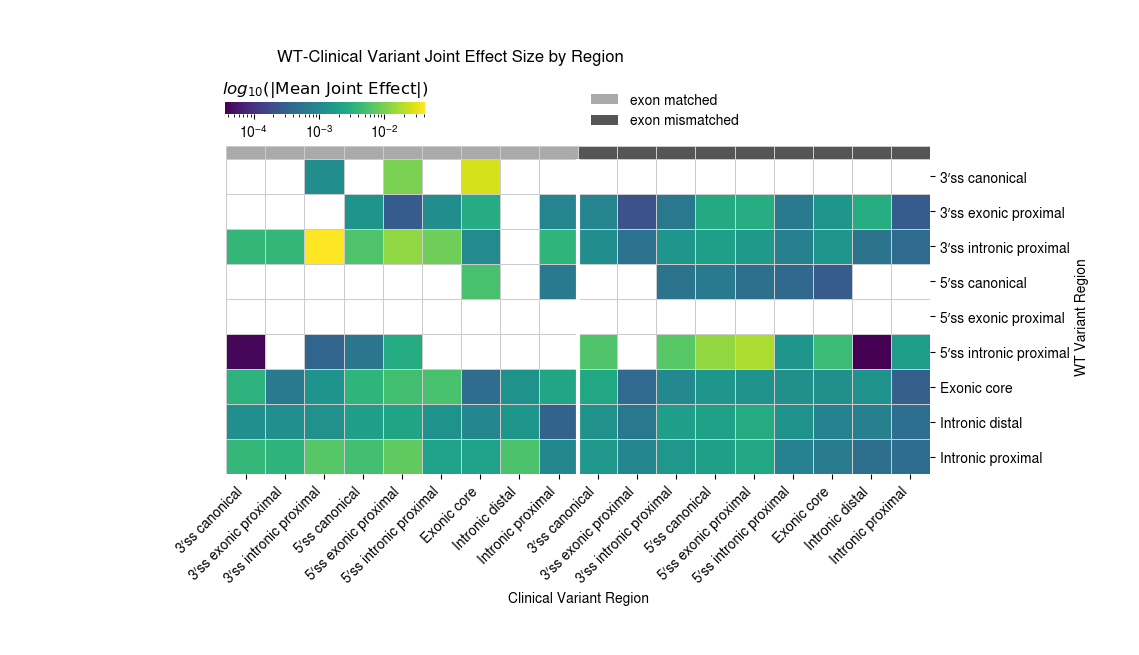

In [ ]:
exclude_annot = ["MANE exons", "MANE introns", 
                # "Exon body"
                ]
merged_clustermap = ab.plot_merged_clustermaps(matrices,   figsize=(10, 5),
                                    exclude_rows=exclude_annot,
                                    exclude_cols=exclude_annot,
                                    annotate_values=False,
                                    log_color_scale=True, row_cluster=False, col_cluster=False)

merged_clustermap['fig'].savefig('manuscript/fig/spliceai_annotation_heatmap.pdf', **utils.FIG_SAVE_KWARGS)

In [71]:
# # Mask NaNs before clustering to avoid errors
# # Log the color scale (add small constant to avoid log(0))
# import numpy as np
# log_matrix = np.log10(matrix.fillna(0) + 1e-6)
# # The error is caused by passing a "text" key in annot_kws, which is not a valid argument for sns.clustermap.
# # Instead, to show the original (unlogged) values as annotations, pass annot=matrix.round(3) directly.
# g = sns.clustermap(
#     log_matrix, 
#     cmap="viridis", 
#     mask=matrix.isna(),
#     annot=matrix.round(3), 
#     fmt=".3f",
#     linewidths=0.5,  # Add faint grid lines
#     linecolor="#cccccc"  # Light gray grid lines
# )
# g.ax_heatmap.set_xlabel("Clinical Variant")
# g.ax_heatmap.set_ylabel("WT Variant")
# g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha="right")
# g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
# g.ax_heatmap.figure.tight_layout()
# g.ax_heatmap.figure.show()

All clinical variants in one ridge regression model.

WARNING: This approach is confounded by the fact that many of the WT variants were not seen by a given clinical variant due to the small window size of SpliceAI (10kb). Thus, an interaction score of 0 could mean either that there is truly not WT-clinical variant interaction, or that the WT variant just wans't fed into SpliceAI at inference time.

In [42]:
# wtvariants_to_vep_linear_model_out = ab.wtvariants_to_vep_linear_model(Xwt, y_vep, 
#                                                                        add_positions=True)

# # Merge with variant metadata
# ridge_df = wtvariants_to_vep_linear_model_out["interaction_df"]
# ridge_df = ridge_df.merge(bed, on="site",how="left") 

### Explore WT-Clinical variant interaction coefficients

Heatmap.

/home/schilder/projects/VEP_DNA/src/analysis/matrices.py:161: RuntimeWarning: All-NaN axis encountered
  binned_rows.append(agg_func(row_slice, axis=0))


Normalizing columns
(156, 302)


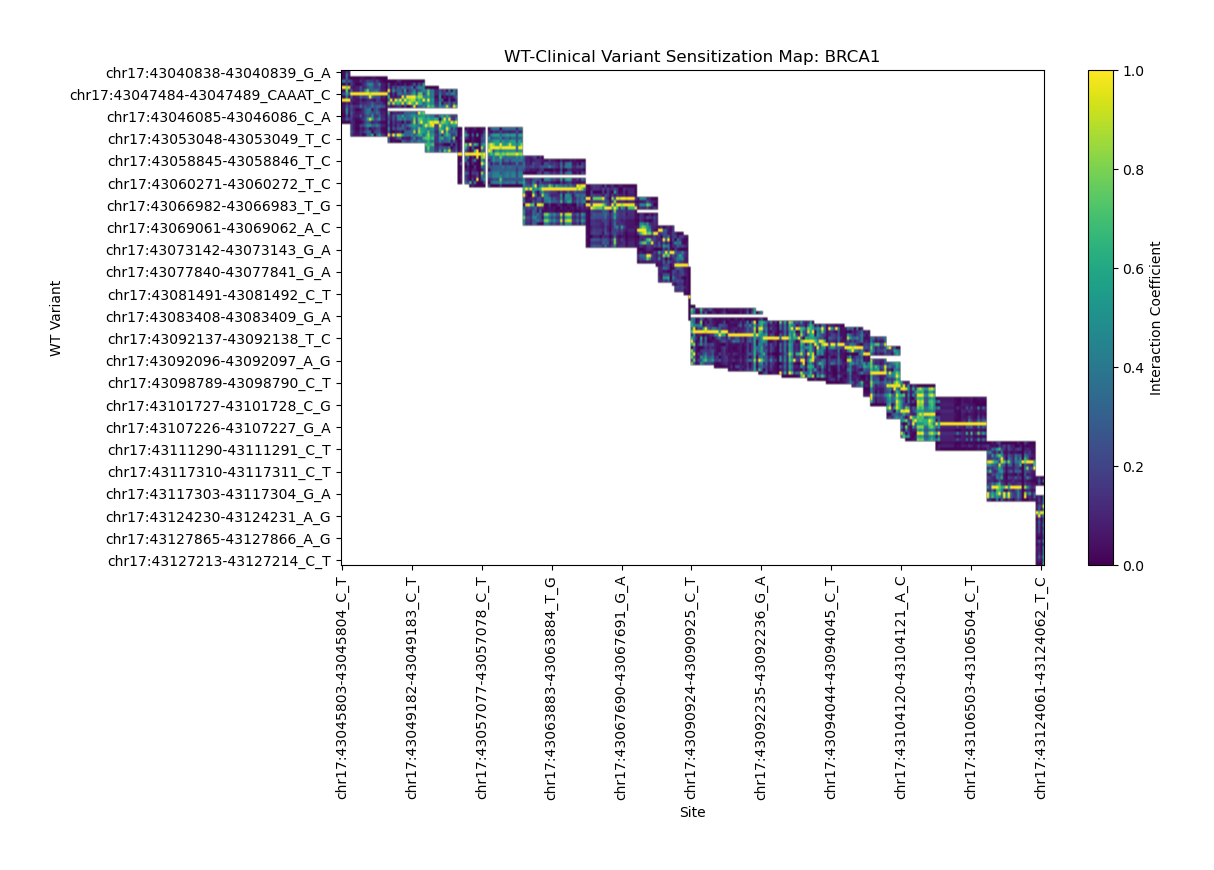

In [72]:
# Xcoef_tmp = wtvariants_to_vep_linear_model_out["coef_matrix_abs"]

# Extract and concatenate the coefficients for each clinical variant
# coef_list = []
# for y in y_vep.columns:
#     coef_df = pd.DataFrame(models[y]['coef_matrix_abs'], columns=[y]) 
#     # coef_df = mc.minmax_normalize(coef_df, procedure=["cols",], verbose=False)
#     coef_list.append(coef_df)
# Xcoef_tmp = pd.concat(coef_list, axis=0)
# Xcoef_tmp = coef_df.copy()

Xcoef_tmp_tmp = Xcoef.copy() 

# Min-max normalize the columns of Xcoef_tmp
# Xcoef_tmp_tmp = mc.minmax_normalize(Xcoef_tmp, procedure=["cols",])
# Xcoef_tmp = np.log10(Xcoef_tmp + 1e-6)

# Xcoef_tmp = mc.bin_matrix_col(Xcoef_tmp, bin_size=5,) 
Xcoef_tmp_tmp = mc.bin_matrix_row(Xcoef_tmp_tmp, bin_size=20, use_first_index=True)  
Xcoef_tmp_tmp = mc.minmax_normalize(Xcoef_tmp_tmp, procedure=["cols",])
# Xcoef_tmp_tmp = mc.expand_matrix(Xcoef_tmp_tmp, target_size_x=Xcoef_tmp_tmp.shape[0], target_size_y=Xcoef_tmp_tmp.shape[1])
# Xcoef_tmp_tmp = pd.DataFrame(Xcoef_tmp_tmp, columns=Xcoef_tmp_tmp.columns, index=Xcoef_tmp_tmp.index)

# Xcoef_tmp_tmp.fillna(0, inplace=True)


print(Xcoef_tmp_tmp.shape)

plt.figure(figsize=(12, 8))
im = plt.imshow(Xcoef_tmp_tmp.values, aspect='auto', cmap='viridis')
plt.colorbar(im, label="Interaction Coefficient")
plt.xlabel("Site")
plt.ylabel("WT Variant")
plt.title(f"WT-Clinical Variant Sensitization Map: {gene}")
plt.xticks(
    ticks=range(0, Xcoef_tmp_tmp.shape[1], max(1, Xcoef_tmp_tmp.shape[1] // 10)),
    labels=Xcoef_tmp_tmp.columns[::max(1, Xcoef_tmp_tmp.shape[1] // 10)],
    rotation=90
)
plt.yticks(
    ticks=range(0, Xcoef_tmp_tmp.shape[0], max(1, Xcoef_tmp_tmp.shape[0] // 20)),
    labels=Xcoef_tmp_tmp.index[::max(1, Xcoef_tmp_tmp.shape[0] // 20)]
)
plt.tight_layout()
plt.show()


Clustermap.

Normalizing rows


Text(0.5, 0.98, 'WT-Clinical Variant Sensitization Map: BRCA1')

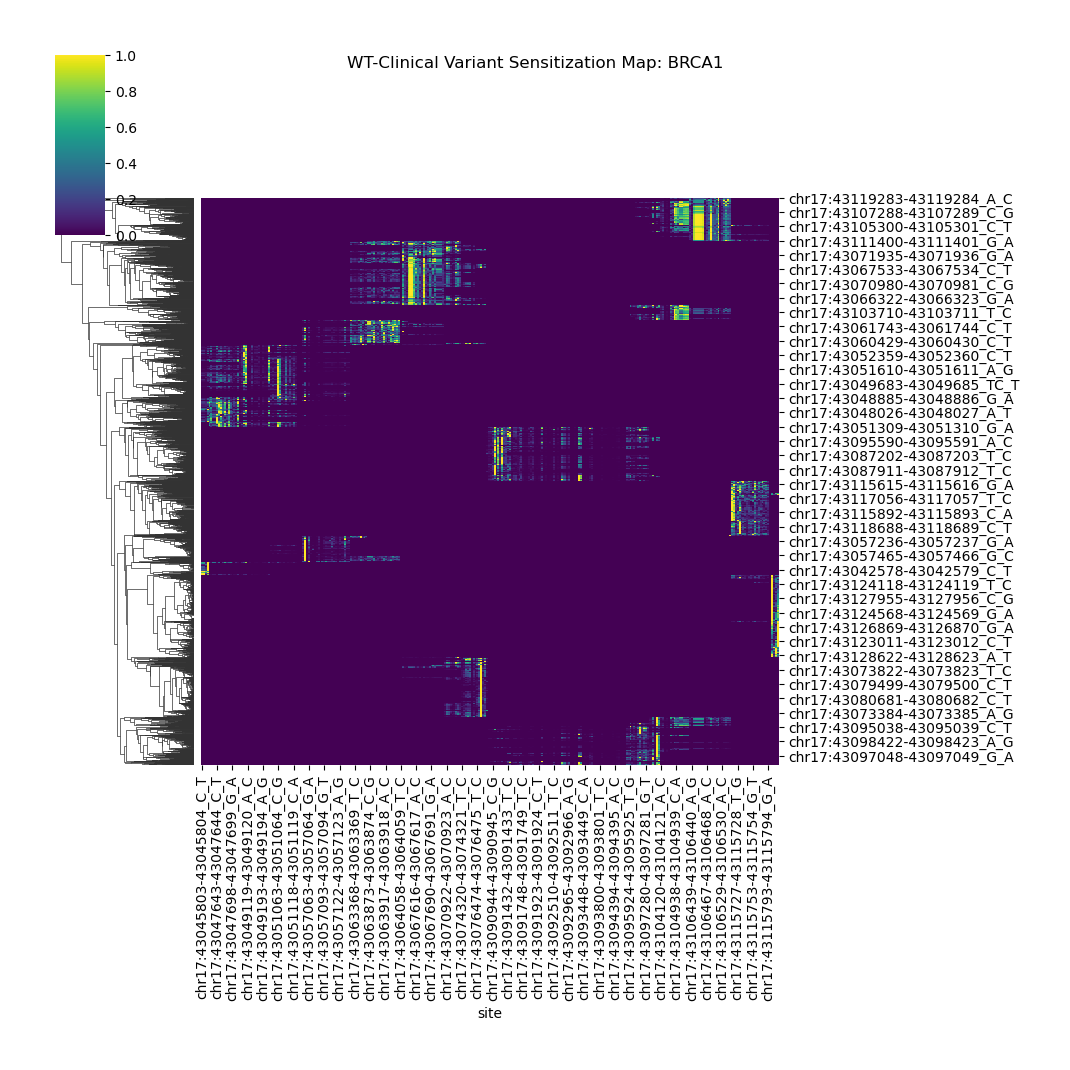

In [73]:
# Xcoef_tmp = wtvariants_to_vep_linear_model_out["coef_matrix_abs"]
Xcoef_tmp = Xcoef.copy()
Xcoef_tmp = Xcoef_tmp[Xcoef_tmp.nunique(axis=1) > 1]
 
Xcoef_tmp.fillna(0, inplace=True)
Xcoef_tmp = mc.minmax_normalize(Xcoef_tmp, procedure=["rows",])


g = sns.clustermap(Xcoef_tmp, 
                    cmap='viridis', 
                    row_cluster=True,
                    col_cluster=False,
                    # vmin=-1, vmax=1
                    ) 
g.fig.suptitle(f"WT-Clinical Variant Sensitization Map: {gene}")


## WT-Clinical Variant Joint Effect Size vs. Genomic Distance

Test whether there's a relationships between genomic position distance and interaction strength.

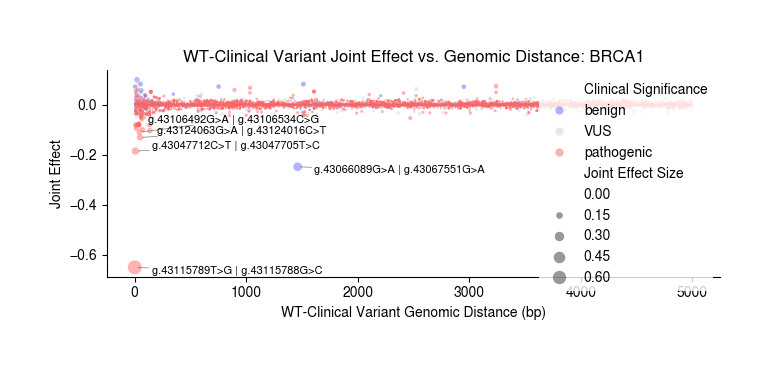

In [88]:
from adjustText import adjust_text

palette = utils.get_clinsig_palette()
plot_df = ridge_df.copy().rename(columns={
    "CLNSIG_simple": "Clinical Significance",
    "interaction_strength": "Joint Effect Size"
})
plot_df["Clinical Significance"] = plot_df["Clinical Significance"].replace({"vus":"VUS"})

plot_df = utils.sort_by_clinsig(plot_df, clinsig_col="Clinical Significance")
plot_df = plot_df.loc[plot_df["wt_position"] != plot_df["clinical_position"]]

split_col = plot_df["wt_variant"].str.split(":|-|_", expand=True)
plot_df["wt_label"] = "g."+split_col[1]+split_col[3]+">"+split_col[4]
plot_df["clinical_label"] = plot_df["CLNHGVS"].str.split(":").str[1]

plt.figure(figsize=(7, 3))
g = sns.scatterplot(
    x="position_distance", 
    y="interaction_strength_signed",
    size="Joint Effect Size",
    hue="Clinical Significance",
    palette=palette,
    sizes=(0.0001,100),
    alpha=0.5,
    data=plot_df
)
plt.title(f"WT-Clinical Variant Joint Effect vs. Genomic Distance: {gene}")
plt.xlabel("WT-Clinical Variant Genomic Distance (bp)")
plt.ylabel("Joint Effect")

# Label the top 5 strongest interactions
top5 = plot_df.nlargest(5, "Joint Effect Size")
texts = []
for _, row in top5.iterrows():
    label = f"{row['wt_label']} | {row['clinical_label']}"
    texts.append(
        plt.text(
            row["position_distance"], 
            row["interaction_strength_signed"], 
            label, 
            fontsize=8, 
            color="black"
        )
    )
adjust_text(texts, arrowprops=dict(arrowstyle="->", color='gray', lw=0.5))
g.legend_.get_frame().set_linewidth(0)
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

g_rasterized = utils.rasterize_figure({"fig": g.figure})

# NOTE: It's necessary to save as PNG bc there's so many data points that the PDF becomes to massive
g_rasterized["fig"].savefig(f"manuscript/fig/spliceai_interaction_strength_by_position_distance.pdf", **utils.FIG_SAVE_KWARGS)

Show interaction strength by clinical significance.

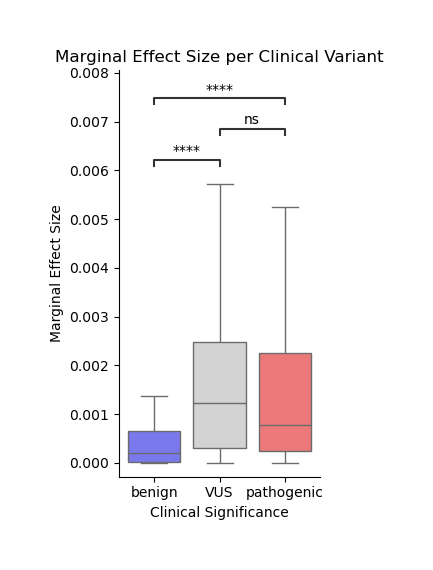

In [25]:
clinsig_boxplot = ab.plot_clinsig_interaction_strength(
    ridge_df=ridge_df,  
    palette=utils.get_clinsig_palette(),
    title="Marginal Effect Size per Clinical Variant",
    site_col="site",
    x="CLNSIG_simple",
    xlabel_rotation=0,
    figsize=(3, 5)
)
clinsig_boxplot["fig"].savefig(f"tmp/spliceai_interaction_strength_by_clinsig.pdf", **utils.FIG_SAVE_KWARGS)

Test whether there's a relationship between the LD and interaction strength.

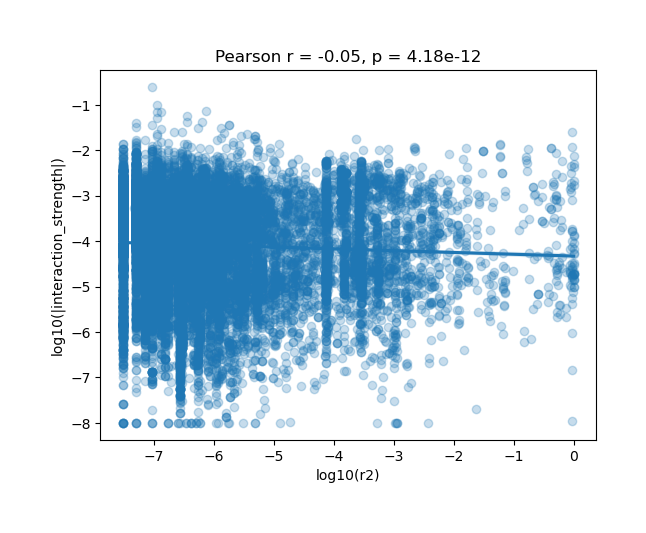

In [78]:
if 'Xld' not in globals():
    Xld = np.corrcoef(Xwt.values, rowvar=False) 

# Precompute mapping from wt_variant and clinical_position to Xld indices for speed
pos_to_idx = {int(str(name).split(":")[1].split("-")[0]): i for i, name in enumerate(Xwt.columns)}

def fast_get_r(row):
    x_idx = pos_to_idx.get(row["wt_position"], None)
    y_idx = pos_to_idx.get(row["clinical_position"], None)
    if x_idx is not None and y_idx is not None:
        return Xld[x_idx, y_idx]
    else:
        return np.nan

ridge_df["r"] = ridge_df.apply(fast_get_r, axis=1)
ridge_df["r2"] = ridge_df["r"]**2


from scipy.stats import pearsonr

# Compute log10 values
log_r2 = np.log10(ridge_df["r2"] + 1e-8)
log_interaction_strength = np.log10(ridge_df["interaction_strength"].abs() + 1e-8)

# Remove NaNs and infs for correlation and plotting
mask = (
    log_r2.notna() & log_interaction_strength.notna() &
    np.isfinite(log_r2) & np.isfinite(log_interaction_strength)
)
log_r2_clean = log_r2[mask]
log_interaction_strength_clean = log_interaction_strength[mask]

# Plot
sns.regplot(
    x=log_r2_clean, 
    y=log_interaction_strength_clean,
    scatter_kws={'alpha':0.25}
)
plt.xlabel("log10(r2)")
plt.ylabel("log10(|interaction_strength|)")

# Pearson correlation
if len(log_r2_clean) > 1:
    pearson_r, pearson_p = pearsonr(log_r2_clean, log_interaction_strength_clean)
    plt.title(f"Pearson r = {pearson_r:.2f}, p = {pearson_p:.2e}")
else:
    plt.title("Not enough data for Pearson correlation")

## Annotate variant sensitization maps







## 🧬 Definition of Splicing Regions

This table defines and names key genomic regions around splice sites, used for splicing-aware variant annotation and model interpretation.

These regions are defined relative to exon-intron boundaries on the **positive strand (+)**.  
For exons on the **negative strand (-)**, the ranges must be **mirrored** accordingly:

- **Upstream becomes downstream**
- **Start and end positions are interpreted in a strand-aware manner**

| Region Type  | Range (relative to exon-intron boundary on + strand) | Length (bp) | Notes                                      | Short Name    |
|-----------------------------------------------|------------------------------------------------------|-------------|-----------------------------------------------------------|---------------|
| **Canonical 5′ss**                            | `[+1, +2]` (intronic)                                | 2 bp        | Core GT splice site                                       | `5ss_can`     |
| **5′ss intronic proximal**                    | `[+3, +6]` (intronic)                                | 4 bp        | Extended donor consensus                                  | `5ss_iprox`   |
| **5′ss exonic proximal**                      | `[-3, 0]` (exonic)                                   | 3 bp        | Extended donor consensus                      | `5ss_eprox`   |
| **Canonical 3′ss**                            | `[-2, -1]` (intronic)                                | 2 bp        | Core AG splice site                                       | `3ss_can`     |
| **3′ss intronic proximal**                    | `[-17, -3]` (intronic)                               | 15 bp       | Polypyrimidine tract and branchpoint proximity            | `3ss_iprox`   |
| **Branchpoint region**                        | `[-40, -18]` (intronic)                              | 23 bp       | Typical location of lariat-forming branchpoint            | `bp_region`   |
| **3′ss exonic proximal**                      | `[0, +3]` (exonic)                                   | 3 bp        | Extended acceptor consensus                   | `3ss_eprox`   |
| **Exon body excluding 5′ss/3′ss proximal**     | Exon excluding `[-3, +3]` at both ends               | Varies      | Coding region with reduced direct splice regulatory input | `exon_core`   |
---


## 🔖 Notes:

- Ranges are given in **relative coordinates** and must be computed with respect to strand.
- In genomic coordinate systems:
  - For `+` strand exons: ranges apply as shown.
  - For `−` strand exons: ranges must be flipped accordingly, and applied to exon **start** instead of **end** (and vice versa).
- All short names are designed to be used in:
  - BED files (`feature` column)
  - Annotation labels

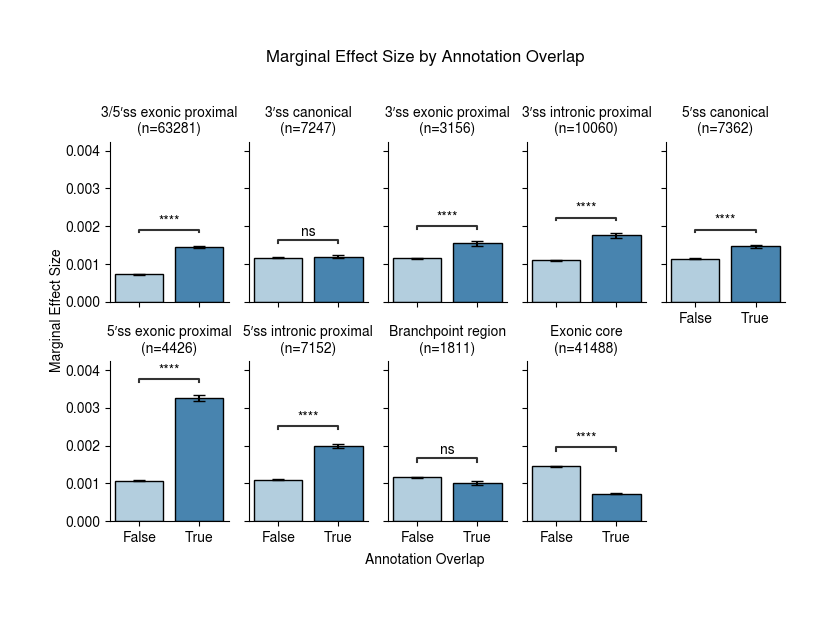

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from statannotations.Annotator import Annotator

exclude_annot = ["mane_introns","mane_exons"]
# Map region short names to full region type names for plotting
region_full_map = {
    "5ss_can": "5′ss canonical",
    "5ss_iprox": "5′ss intronic proximal",
    "5ss_eprox": "5′ss exonic proximal",
    "3ss_can": "3′ss canonical",
    "3ss_iprox": "3′ss intronic proximal",
    "bp_region": "Branchpoint region",
    "3ss_eprox": "3′ss exonic proximal",
    "exon_core": "Exonic core", # (Exon body excluding 5′ss/3′ss exonic proximal)
    "35ss_eprox": "3/5′ss exonic proximal",
    "intron_dist": "Intronic distal", 
    "intron_prox": "Intronic proximal",
    "mane_introns": "MANE introns",
    "mane_exons": "MANE exons",
}
 

# Melt the data to long format for easier plotting
melted = ridge_df.melt(
    id_vars=["interaction_strength","interaction_strength_signed"],
    value_vars=[x for x in region_full_map.keys() if x not in exclude_annot and x in ridge_df.columns],
    var_name="region",
    value_name="in_region"
)
melted.sort_values(by="region", ascending=False, inplace=True)

# Compute mean and standard error for each region/in_region group
agg_df = melted.groupby(["region", "in_region"])["interaction_strength"].agg(['mean', 'count', 'std']).reset_index()

agg_df["region_full"] = agg_df["region"].map(region_full_map)
melted["region_full"] = melted["region"].map(region_full_map)

agg_df["in_region"] = agg_df["in_region"].astype(bool).astype(str)
agg_df["sem"] = agg_df["std"] / agg_df["count"].pow(0.5)

# --- Add count info for facet titles ---
# For each region, get the total count (sum of both in_region True/False)
region_counts = agg_df.set_index("region_full")["count"].to_dict()
# Create a mapping from region_full to "Region Name (n=COUNT)"
region_full_with_count = {k: f"{k}\n(n={region_counts[k]})" for k in region_counts}
agg_df["region_full_count"] = agg_df["region_full"].map(region_full_with_count)
melted["region_full_count"] = melted["region_full"].map(region_full_with_count)

# Plot as barplot, one facet per region, with standard error bars
aspect = .6
g = sns.catplot(
    data=agg_df,
    x="in_region",
    y="mean",
    hue="in_region",
    kind="bar",
    col="region_full_count",
    palette="Blues",
    col_wrap=5,  # <-- change number of columns/rows
    sharey=True,
    sharex=True,
    height=2.5,
    aspect=aspect,
    legend=False,
    errorbar=None, 
    edgecolor="black",   # Add black lines around the bars
    linewidth=1,       # Set the thickness of the black lines
)

# Add error bars manually
for ax, (region, subdf) in zip(g.axes.flatten(), agg_df.groupby("region_full_count")):
    for i, (idx, row) in enumerate(subdf.iterrows()):
        bars = ax.patches
        bar_idx = i
        if bar_idx < len(bars):
            bar = bars[bar_idx]
            x = bar.get_x() + bar.get_width() / 2
            y = bar.get_height()
            ax.errorbar(
                x, y, yerr=row["sem"], fmt='none', c='black', capsize=4, lw=1.5
            )

# Add statistical annotation using statannotations.Annotator
# For each region, compare in_region True vs False, accounting for the aspect (bar width) in the plot
for ax, region in zip(g.axes.flatten(), agg_df["region_full_count"].unique()):
    region_data = melted[melted["region_full_count"] == region]
    # Only annotate if both groups have at least 2 values
    n_true = (region_data["in_region"] == True).sum()
    n_false = (region_data["in_region"] == False).sum()
    if n_true > 1 and n_false > 1:
        pairs = [(True, False)] 
        # Make brackets as tight as possible by setting bracket_group_distance and line_width to small values
        y_offset = 0.05 / aspect if aspect > 0 else 0.05
        annotator = Annotator(
            ax=ax,
            pairs=pairs,
            data=region_data,
            x="in_region",
            y="interaction_strength",
            order=[True, False],
        )
        annotator.configure(
            test='t-test_ind',
            text_format='star',
            loc='inside',
            verbose=0,
            line_offset_to_group=y_offset, 
        )
        annotator.apply_and_annotate()

g.set_titles("{col_name}")
g.set_axis_labels("", "")
g.fig.text(0, 0.5, "Marginal Effect Size", va='center', rotation='vertical')
g.fig.text(0.5, 0, "Annotation Overlap", ha='center', va='center')
g.fig.suptitle("Marginal Effect Size by Annotation Overlap",y=1.02
# x=0.33, y=1.02
)

g.savefig(f"manuscript/fig/spliceai_interaction_strength_by_region.pdf", **utils.FIG_SAVE_KWARGS)
plt.tight_layout()
plt.show()

In [217]:
# import seaborn as sns

# pow = 2
# # Xcoef_tmp = wtvariants_to_vep_linear_model_out["coef_matrix_abs"]**pow
# Xcoef_tmp_orig = Xcoef_tmp.copy() 

# # Min-max normalize the columns of Xcoef_tmp
# Xcoef_tmp = mc.minmax_normalize(Xcoef_tmp, procedure=["cols",])
# # Xcoef_tmp = np.log10(Xcoef_tmp + 1e-6)

# # Xcoef_tmp = mc.bin_matrix_col(Xcoef_tmp, bin_size=5,) 
# Xcoef_tmp = mc.bin_matrix_row(Xcoef_tmp, bin_size=10, use_first_index=True)  
# # Xcoef_tmp = mc.minmax_normalize(Xcoef_tmp, procedure=["cols",])
# # Xcoef_tmp = mc.expand_matrix(Xcoef_tmp, target_size_x=Xcoef_tmp.shape[0], target_size_y=Xcoef_tmp.shape[1])
# Xcoef_tmp = pd.DataFrame(Xcoef_tmp, columns=Xcoef_tmp_orig.columns, index=Xcoef_tmp.index)
# Xcoef_tmp.fillna(0, inplace=True)

# col_colors = None
# row_colors = None
# if annot_cols:
#     col_colors_dict = {}
#     # All annotations are binary, so use a fixed palette for 0/1
#     binary_palette = {1: "#000000", 0: "#f5f5f5"}  # 0 is very light gray
#     for ann_col in annot_cols:
#         ann_values = ridge_df[["site",ann_col]].drop_duplicates().set_index("site").reindex(Xcoef_tmp.columns)
#         # Map 0/1 to colors
#         col_colors_dict[ann_col] = ann_values[ann_col].map(binary_palette)
        
#     # Combine into a DataFrame for seaborn
#     col_colors = pd.DataFrame(col_colors_dict, index=Xcoef_tmp.columns) 


# # Add row colors
# rc1 = col_colors.copy()
# rc1["wt_position"] = rc1.index.str.split(":").str[1].str.split("-").str[0].astype(int) 
# rc2 = col_colors.copy()
# rc2["wt_position"] = rc2.index.str.split(":").str[1].str.split("-").str[1].str.split("_").str[0].astype(int)
# row_colors = pd.concat([ rc1, rc2], axis=0, ignore_index=True).drop_duplicates(subset=["wt_position"]).set_index("wt_position").sort_index()
# row_variants = pd.DataFrame({"wt_variant": Xcoef_tmp.index, "wt_position": Xcoef_tmp.index.str.split(":").str[1].str.split("-").str[0].astype(int)}, index=Xcoef_tmp.index)
# row_colors = row_colors.merge(row_variants, on="wt_position", how="inner").set_index("wt_variant").drop(columns=["wt_position"])

# # Helper to extract Mb position from site string
# def site_to_mb(site):
#     # expects e.g. "chr17:43040838-43040839_G_A"
#     try:
#         pos = int(site.split(":")[1].split("-")[0])
#         return pos / 1e6
#     except Exception:
#         return None 
# # Get Mb positions for x (sites) and y (wt variants)
# x_mb = [site_to_mb(s) for s in Xcoef_tmp.columns]
# y_mb = [site_to_mb(s) for s in Xcoef_tmp.index]

# # Use seaborn clustermap
# g = sns.clustermap(
#     Xcoef_tmp,
#     cmap="viridis",
#     row_cluster=False,
#     col_cluster=False,

#     col_colors=col_colors,
#     row_colors=row_colors,
    
#     figsize=(12, 8 + 0.3 * len(annot_cols)),
#     xticklabels=True,
#     yticklabels=True,
#     cbar_kws={"label": "Absolute Interaction Score"},
#     dendrogram_ratio=(.1, .2),
#     # Place colorbar to the right, vertically centered on the heatmap
#     cbar_pos=(0.7, 0.3, 0.015, 0.4),
# )

# # Add vertical padding between heatmap and col_colors
# if hasattr(g, "ax_col_colors") and g.ax_col_colors is not None:
#     # Move the col_colors axis up a bit to add padding
#     pos = g.ax_col_colors.get_position()
#     # Increase the bottom and decrease the height to add space below
#     pad = 0.01  # adjust as needed for more/less padding
#     g.ax_col_colors.set_position([pos.x0, pos.y0 + pad, pos.width, pos.height - pad])

# # Move annotation ytick labels (for col_colors) to the left if present
# if hasattr(g, "ax_col_colors") and g.ax_col_colors is not None:
#     g.ax_col_colors.yaxis.tick_left()
#     g.ax_col_colors.yaxis.set_label_position("left")
#     g.ax_col_colors.yaxis.set_ticks_position('left')

# g.ax_heatmap.set_xlabel("Clinical Variant Position (Mb)")
# g.ax_heatmap.set_ylabel("WT Variant Position (Mb)")
# g.ax_col_colors.set_title(f"WT-Clinical Variant Sensitization Map: {gene}")

# # Set x/y ticks to Mb positions, less dense for large matrices
# if Xcoef_tmp.shape[1] > 20:
#     xtick_idx = range(0, Xcoef_tmp.shape[1], max(1, Xcoef_tmp.shape[1] // 6))
# else:
#     xtick_idx = range(Xcoef_tmp.shape[1])
# g.ax_heatmap.set_xticks(xtick_idx)
# g.ax_heatmap.set_xticklabels(
#     [f"{x_mb[i]:.2f}" if x_mb[i] is not None else "" for i in xtick_idx],
#     rotation=90
# )

# if Xcoef_tmp.shape[0] > 40:
#     ytick_idx = range(0, Xcoef_tmp.shape[0], max(1, Xcoef_tmp.shape[0] // 6))
# else:
#     ytick_idx = range(Xcoef_tmp.shape[0])
# g.ax_heatmap.set_yticks(ytick_idx)
# g.ax_heatmap.set_yticklabels(
#     [f"{y_mb[i]:.2f}" if y_mb[i] is not None else "" for i in ytick_idx],
#     rotation=0,
#     ha='left',  # align right for left side
#     va='center'
# )

# # Move y-axis tick labels and label to the left side for both heatmap and annotation colorbar
# g.ax_heatmap.yaxis.tick_right()
# g.ax_heatmap.yaxis.set_label_position("right")
# g.ax_heatmap.yaxis.set_ticks_position('right')
 
# g.savefig(f"tmp/spliceai_sensitization_map.png", **utils.FIG_SAVE_KWARGS)
# plt.tight_layout()
# plt.show()


## Compare variant sensitization maps to ABC maps


Test whether there is substantial enrichment (or any overlap) between WT-Clinical variant interactions we derived from our sensitization maps, and the interctions defined in functional datasets like Activity By Contact (ABC) maps.


Data source:
https://www.engreitzlab.org/resources

In [ ]:
# abc = pl.scan_csv("https://mitra.stanford.edu/engreitz/oak/public/Nasser2021/AllPredictions.AvgHiC.ABC0.015.minus150.ForABCPaperV3.txt.gz", 
#                   separator="\t").filter(
#                       pl.col("chr") == chrom
#                       ).collect().to_pandas()

abc = pd.read_csv("https://mitra.stanford.edu/engreitz/oak/public/Nasser2021/AllPredictions.AvgHiC.ABC0.015.minus150.ForABCPaperV3.txt.gz", 
                  sep="\t")
print(abc.shape)
abc.head() 

In [156]:
import src.pyliftover as pf

abc_chrom = pf.liftover(
    df=abc.loc[(abc["chr"] == chrom)].copy(),
    from_build='hg19',
    to_build='hg38',
    chrom_col='chr',
    position_cols=['start', 'end']
)

Define anchors around each ABC contact pair (+/- `anchor_size` at each end). 

If the clinical variant falls in one anchor and the WT variant falls in the other corresponding anchor (or vice versa), we can consider this a "hit".

In [ ]:
import pyranges as pr
import pandas as pd

print("Filtering ABC contacts to gene region...")

anchor_size = 500
min_interaction_strength = 0.01

# Subset to gene region (with anchor padding)
abc_sub = abc_chrom.loc[(abc_chrom["start_hg38"] >= gene_min_pos-anchor_size) & (abc_chrom["end_hg38"] <= gene_max_pos+anchor_size)].copy()
# Aggregate by anchor region
abc_sub = abc_sub.groupby(["chr","start_hg38","end_hg38","name","class"]).agg({"ABC.Score": "max"}).reset_index()
if abc_sub.empty:
    raise ValueError("abc_sub contains no remaining rows")
print(f"ABC contacts in region: {len(abc_sub)}")



# --- Efficient anchor construction using PyRanges ---
print("Defining ABC anchors (PyRanges)...") 
anchor1 = pr.PyRanges(
    pd.DataFrame({
    "Chromosome": abc_sub["chr"].values,
    "Start": (abc_sub["start_hg38"] - anchor_size).values,
    "End": (abc_sub["start_hg38"] + anchor_size).values,
    "anchor_id": abc_sub.index.values,
    "anchor_type": ["anchor1"] * len(abc_sub)
    })
)
anchor2 = pr.PyRanges(
    pd.DataFrame({
    "Chromosome": abc_sub["chr"].values,
    "Start": (abc_sub["end_hg38"] - anchor_size).values,
    "End": (abc_sub["end_hg38"] + anchor_size).values,
    "anchor_id": abc_sub.index.values,
    "anchor_type": ["anchor2"] * len(abc_sub)
    })
)
abc_anchors_pr = pr.concat([anchor1, anchor2])
print(f"Total ABC anchors: {len(abc_anchors_pr)}")

# --- Ridge variant PyRanges ---
print("Preparing ridge variant PyRanges...")

ridge_df_sub = ridge_df.loc[ridge_df['interaction_strength'] > min_interaction_strength].copy()
ridge_df_sub["chr"] = ridge_df_sub["site"].str.split(":").str[0]

wt_pr = pr.PyRanges(
    pd.DataFrame({
    "Chromosome": ridge_df_sub["chr"].values,
    "Start": ridge_df_sub["wt_position"].values,
    "End": (ridge_df_sub["wt_position"] + 1).values,
    "ridge_id": ridge_df_sub.index.values,
        "var_type": ["wt"] * len(ridge_df_sub)
    })
)
clin_pr = pr.PyRanges(
    pd.DataFrame({
    "Chromosome": ridge_df_sub["chr"].values,
    "Start": ridge_df_sub["clinical_position"].values,
    "End": (ridge_df_sub["clinical_position"] + 1).values,
    "ridge_id": ridge_df_sub.index.values,
    "var_type": ["clinical"] * len(ridge_df_sub)
    })
)

ridge_vars_pr = pr.concat([wt_pr, clin_pr])
print(f"Total ridge variant positions: {len(ridge_vars_pr)}")

# --- Overlap: join in both directions, then groupby in PyRanges ---
print("Finding overlaps between ridge variants and ABC anchors (PyRanges)...")
overlaps = ridge_vars_pr.join(abc_anchors_pr, suffix="_anchor")
overlap_df = overlaps.df
print(f"Total overlaps found: {len(overlap_df)}")

# --- Use groupby in pandas for fast anchor-pair matching ---
print("Finding ridge-ABC pairs with both wt and clinical in different anchors (fast groupby)...")
# Only keep necessary columns
overlap_df = overlap_df[["ridge_id", "var_type", "anchor_id", "anchor_type"]]

# Group by ridge_id and anchor_id, collect anchor_types and var_types
grouped = overlap_df.groupby(["ridge_id", "anchor_id"])
def anchor_pair_match(df):
    types = set(zip(df["var_type"], df["anchor_type"]))
    # Must have one (wt, anchor1) and one (clinical, anchor2) OR
    # one (wt, anchor2) and one (clinical, anchor1)
    return (
        (("wt", "anchor1") in types and ("clinical", "anchor2") in types) or
        (("wt", "anchor2") in types and ("clinical", "anchor1") in types)
    )
mask = grouped.filter(anchor_pair_match)
matches = mask.drop_duplicates(subset=["ridge_id", "anchor_id"])[["ridge_id", "anchor_id"]]

print(f"Number of matching ridge-ABC pairs: {len(matches)}")

# Merge back to get full ridge_df and abc_chrom info
if not matches.empty:
    print("Merging matches with ridge_df and abc_sub for full annotation...")
    matches = matches.merge(ridge_df_sub.reset_index().rename(columns={"index": "ridge_id"}), on="ridge_id", how="left")
    matches = matches.merge(abc_sub.reset_index().rename(columns={"index": "anchor_id"}), on="anchor_id", how="left")
overlap_df = matches

print("First few rows of overlap_df:")
overlap_df.head()


Filtering ABC contacts to gene region...
ABC contacts in region: 2922
Defining ABC anchors (PyRanges)...
Total ABC anchors: 5844
Preparing ridge variant PyRanges...
Total ridge variant positions: 1455564
Finding overlaps between ridge variants and ABC anchors (PyRanges)...
Total overlaps found: 8926958
Finding ridge-ABC pairs with both wt and clinical in different anchors (fast groupby)...
Number of matching ridge-ABC pairs: 60
Merging matches with ridge_df and abc_sub for full annotation...
First few rows of overlap_df:


,ridge_id,anchor_id,wt_variant,site,interaction_strength,interaction_strength_signed,outlier_type,n_haplotypes,interaction_strength_weighted,clinical_variant,wt_position,clinical_position,position_distance,chrom,chromStart,chromEnd,name,score,REF,ALT,MC_id,MC_term,AF_ESP,AF_EXAC,AF_TGP,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNVC,CLNVCSO,CLNSIGCONF,GENEINFO,MC,ORIGIN,RS,ONC,ONCDN,ONCDISDB,ONCREVSTAT,ONCCONF,SCI,SCIDN,SCIDISDB,SCIREVSTAT,CLNREVSTAT_score,MONDO,MONDO_n,OMIM,OMIM_n,Orphanet,Orphanet_n,MedGen,MedGen_n,MeSH,MeSH_n,CLNSIG_simple,CLNSIG_super_simple,GENE,chr_x,chr_y,start_hg38,end_hg38,ABC.Score
0,109227,1470,chr17:7667128-7667129_G_A,chr17:7669124-7669125_C_T,0.065226,0.065226,more benign,1,0.255394,chr17:7669124-7669125_C_T,7667128,7669124,1996,17,7669124,7669125,chr17:7669124-7669125_C_T,2.0,C,T,SO:0001624,3_prime_UTR_variant,NaN,NaN,0.05112,340463,"Gene:553989,MedGen:C1835398,OMIM:151623,Orphan...",Li-Fraumeni_syndrome_1|Hereditary_cancer-predi...,NC_000017.11:g.7669124C>T,"criteria_provided,_multiple_submitters,_no_con...",Benign,single_nucleotide_variant,SO:0001483,None,TP53:7157,SO:0001624|3_prime_UTR_variant,1,4968187.0,None,None,None,None,None,None,None,None,None,2,[MONDO:MONDO:0015356],1,[OMIM:151623],1,"[Orphanet:524, Orphanet:140162]",2,"[MedGen:C1835398, MedGen:C0027672, MedGen:C366...",3,[MeSH:D009386],1,benign,benign,TP53,chr17,chr17,7667462,7668672,0.037489
1,150584,1470,chr17:7667061-7667062_C_T,chr17:7669124-7669125_C_T,0.050614,-0.050614,more pathogenic,3,0.389668,chr17:7669124-7669125_C_T,7667061,7669124,2063,17,7669124,7669125,chr17:7669124-7669125_C_T,2.0,C,T,SO:0001624,3_prime_UTR_variant,NaN,NaN,0.05112,340463,"Gene:553989,MedGen:C1835398,OMIM:151623,Orphan...",Li-Fraumeni_syndrome_1|Hereditary_cancer-predi...,NC_000017.11:g.7669124C>T,"criteria_provided,_multiple_submitters,_no_con...",Benign,single_nucleotide_variant,SO:0001483,None,TP53:7157,SO:0001624|3_prime_UTR_variant,1,4968187.0,None,None,None,None,None,None,None,None,None,2,[MONDO:MONDO:0015356],1,[OMIM:151623],1,"[Orphanet:524, Orphanet:140162]",2,"[MedGen:C1835398, MedGen:C0027672, MedGen:C366...",3,[MeSH:D009386],1,benign,benign,TP53,chr17,chr17,7667462,7668672,0.037489
2,151356,1470,chr17:7667611-7667612_C_T,chr17:7668539-7668540_G_A,0.050407,0.050407,more benign,3765,13.776133,chr17:7668539-7668540_G_A,7667611,7668539,928,17,7668539,7668540,chr17:7668539-7668540_G_A,2.0,G,A,SO:0001624,3_prime_UTR_variant,NaN,NaN,0.00779,347484,"MedGen:C3661900|MONDO:MONDO:0015356,MeSH:D0093...",not_provided|Hereditary_cancer-predisposing_sy...,NC_000017.11:g.7668539G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign/Likely_benign,single_nucleotide_variant,SO:0001483,None,TP53:7157,SO:0001624|3_prime_UTR_variant,1,114831472.0,None,None,None,None,None,None,None,None,None,2,[MONDO:MONDO:0015356],1,[OMIM:151623],1,"[Orphanet:140162, Orphanet:524]",2,"[MedGen:C3661900, MedGen:C0027672, MedGen:C183...",3,[MeSH:D009386],1,likely_benign,benign,TP53,chr17,chr17,7667462,7668672,0.037489
3,198171,1470,chr17:7667362-7667363_G_A,chr17:7668539-7668540_G_A,0.040745,-0.040745,more pathogenic,4,0.403706,chr17:7668539-7668540_G_A,7667362,7668539,1177,17,7668539,7668540,chr17:7668539-7668540_G_A,2.0,G,A,SO:0001624,3_prime_UTR_variant,NaN,NaN,0.00779,347484,"MedGen:C3661900|MONDO:MONDO:0015356,MeSH:D0093...",not_provided|Hereditary_cancer-predisposing_sy...,NC_000017.11:g.7668539G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign/Likely_benign,single_nucleotide_variant,SO:0001483,None,TP53:7157,SO:0001624|3_prime_UTR_variant,1,114831472.0,None,None,None,None,None,None,None,None,None,2,[MONDO:MONDO:0015356],1,[OMIM:151623],1,"[Orphanet:140162, Orphanet:524]",2,"[MedGen:C3661900, MedGen:C0027672, MedGen:C183...",3,[MeSH:D009386],1,likely_benign,benign,TP53,chr17,chr17,7667462,7668672,0.037489
4,217957,1470,chr17:7667706-7667707_G_A,chr17:7668783-7668784_C_T,0.037679,0.037679,more benign,16,0.776443,chr17:7668783-7668784_C_T,7667706,766

<Axes: xlabel='interaction_strength', ylabel='ABC.Score'>

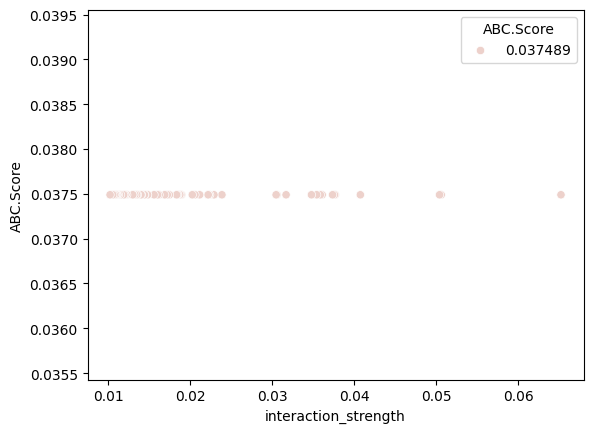

In [219]:
sns.scatterplot(data=overlap_df, x="interaction_strength", y="ABC.Score", hue="ABC.Score")

In [221]:
abc_sub

,chr,start_hg38,end_hg38,ABC.Score
0,chr17,7418979,7419179,0.020327
1,chr17,7429461,7430058,0.016144
2,chr17,7435011,7437248,0.189394
3,chr17,7435012,7435912,0.138041
4,chr17,7435175,7435935,0.147719
...,...,...,...,...
2917,chr17,7922913,7923113,0.024458
2918,chr17,7922927,7923127,0.019590
2919,chr17,7922931,7923131,0.018537
2920,chr17,7923274,7923474,0.015745


In [ ]:
abc_sub["anchor1"] = abc_sub["chr"] +":"+ abc_sub["start_hg38"].astype(str)
abc_sub["anchor2"] = abc_sub["chr"] +":"+ abc_sub["end_hg38"].astype(str)
 
Xabc = mc.fill_coordinates(abc_sub, 
                           full_length=gene_max_pos-gene_min_pos+1,
                           x_id_col='anchor1',
                           y_id_col='anchor2',
                           x_pos_col='start_hg38',
                           y_pos_col='end_hg38',
                           value_col="ABC.Score",
                           aggfunc="max", 
                           )

<string>:26: PerformanceWarning: The following operation may generate 269103118200 cells in the resulting pandas object.


In [ ]:
Xabc = mc.fill_coordinates(abc_sub, 
                           full_length=gene_max_pos-gene_min_pos+1,
                           x_id_col='name',
                            y_id_col='class',
                            x_pos_col='start_hg38',
                            y_pos_col='end_hg38',
                            value_col="ABC.Score",
                            aggfunc="max", 
                            )
Xabc.shape
 

(2530, 2483)

/tmp/ipykernel_3894547/368689104.py:1: FutureWarning: The provided callable <function nanmax at 0x7f5eadb93060> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  Xabc = abc_sub.pivot_table(index="start_hg38", columns="end_hg38", values="ABC.Score", aggfunc=np.nanmax)
<string>:28: RuntimeWarning: All-NaN slice encountered


(2530, 2483)


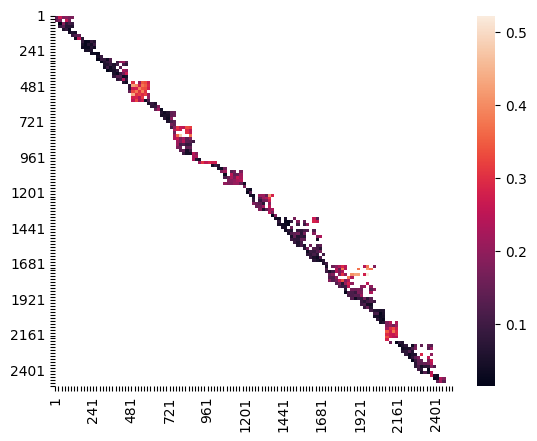

In [211]:
Xabc = abc_sub.pivot_table(index="start_hg38", columns="end_hg38", values="ABC.Score", aggfunc=np.nanmax) 
print(Xabc.shape)

bin_size = 20
Xabc_binned = mc.bin_matrix(Xabc, bin_size=bin_size, agg_func=np.nanmax)

sns.heatmap(Xabc_binned)

mc.label_bins(bin_size=bin_size, n_bins=Xabc.shape[0]//bin_size)